In [1]:
# Connect Google Drive to Colab
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import Python's built-in operating system library
import os

# Main project folder in Google Drive
PROJECT_ROOT = "/content/drive/MyDrive/NNDL_English_Hindi_Translator"

# List of folders needed for the complete project
folders = [
    "data/raw",
    "data/processed",
    "notebooks",
    "tokenizers",
    "saved_models/gru",
    "saved_models/gru_attention",
    "saved_models/transformer",
    "results/plots",
    "results/attention_maps",
    "results/metrics",
    "api",
    "app",
    "logs",
    "docs"
]

# Create every folder
# exist_ok=True means Colab will not give an error
# if the folder already exists
for folder in folders:
    folder_path = os.path.join(PROJECT_ROOT, folder)
    os.makedirs(folder_path, exist_ok=True)

print("All project folders created successfully!")

All project folders created successfully!


In [4]:
# Display the project folder structure

for root, dirs, files in os.walk(PROJECT_ROOT):
    level = root.replace(PROJECT_ROOT, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    sub_indent = "    " * (level + 1)

    for file in files:
        print(f"{sub_indent}{file}")

NNDL_English_Hindi_Translator/
    data/
        raw/
        processed/
    notebooks/
    tokenizers/
    saved_models/
        gru/
        gru_attention/
        transformer/
    results/
        plots/
        attention_maps/
        metrics/
    api/
    app/
    logs/
    docs/


In [5]:
# ============================================================
# STEP 2: DEFINE PROJECT AND DATASET PATHS
# ============================================================

import os

# Main project folder
PROJECT_ROOT = "/content/drive/MyDrive/NNDL_English_Hindi_Translator"

# Folder containing the original dataset files
RAW_DATA_DIR = os.path.join(PROJECT_ROOT, "data", "raw")

# Exact paths of our three dataset files
TRAIN_PATH = os.path.join(
    RAW_DATA_DIR,
    "train-00000-of-00001.parquet"
)

VALIDATION_PATH = os.path.join(
    RAW_DATA_DIR,
    "validation-00000-of-00001.parquet"
)

TEST_PATH = os.path.join(
    RAW_DATA_DIR,
    "test-00000-of-00001.parquet"
)

print("Project root:")
print(PROJECT_ROOT)

print("\nRaw data folder:")
print(RAW_DATA_DIR)

Project root:
/content/drive/MyDrive/NNDL_English_Hindi_Translator

Raw data folder:
/content/drive/MyDrive/NNDL_English_Hindi_Translator/data/raw


In [6]:
# ============================================================
# STEP 3: VERIFY DATASET FILES
# ============================================================

# Store dataset names and their paths together.
dataset_files = {
    "Training": TRAIN_PATH,
    "Validation": VALIDATION_PATH,
    "Test": TEST_PATH
}

# Check whether every file exists in Google Drive.
for dataset_name, file_path in dataset_files.items():

    if os.path.exists(file_path):
        print(f"✅ {dataset_name} dataset found")
        print(f"   Path: {file_path}")

    else:
        print(f"❌ {dataset_name} dataset NOT found")
        print(f"   Expected path: {file_path}")

    print()

✅ Training dataset found
   Path: /content/drive/MyDrive/NNDL_English_Hindi_Translator/data/raw/train-00000-of-00001.parquet

✅ Validation dataset found
   Path: /content/drive/MyDrive/NNDL_English_Hindi_Translator/data/raw/validation-00000-of-00001.parquet

✅ Test dataset found
   Path: /content/drive/MyDrive/NNDL_English_Hindi_Translator/data/raw/test-00000-of-00001.parquet



In [7]:
# ============================================================
# STEP 4: CHECK PARQUET DATASET METADATA
# ============================================================

import pyarrow.parquet as pq

# Open each parquet file using PyArrow.
train_parquet = pq.ParquetFile(TRAIN_PATH)
validation_parquet = pq.ParquetFile(VALIDATION_PATH)
test_parquet = pq.ParquetFile(TEST_PATH)

# Display number of rows.
print("DATASET SIZE")
print("-" * 40)

print(f"Training rows   : {train_parquet.metadata.num_rows:,}")
print(f"Validation rows : {validation_parquet.metadata.num_rows:,}")
print(f"Test rows       : {test_parquet.metadata.num_rows:,}")

DATASET SIZE
----------------------------------------
Training rows   : 1,659,083
Validation rows : 520
Test rows       : 2,507


In [8]:
# ============================================================
# STEP 5: CHECK DATASET SCHEMA
# ============================================================

# The schema tells us what columns/fields are stored
# inside the parquet dataset.

print("TRAINING DATASET SCHEMA")
print("-" * 40)

print(train_parquet.schema)

TRAINING DATASET SCHEMA
----------------------------------------
required group field_id=-1 schema {
  optional group field_id=-1 translation {
    optional binary field_id=-1 en (String);
    optional binary field_id=-1 hi (String);
  }
}



In [9]:
# ============================================================
# STEP 6: LOAD A SMALL SAMPLE OF THE TRAINING DATA
# ============================================================

import pandas as pd

# Read only the first 10 rows from the training parquet file.
# This is enough to inspect the structure and sample translations.
train_sample = pd.read_parquet(TRAIN_PATH).head(10)

print("Sample loaded successfully.")
print("Shape:", train_sample.shape)

train_sample

Sample loaded successfully.
Shape: (10, 1)


,translation
0,{'en': 'Give your application an accessibility...
1,"{'en': 'Accerciser Accessibility Explorer', 'h..."
2,{'en': 'The default plugin layout for the bott...
3,{'en': 'The default plugin layout for the top ...
4,{'en': 'A list of plugins that are disabled by...
5,"{'en': 'Highlight duration', 'hi': 'अवधि को हा..."
6,{'en': 'The duration of the highlight box when...
7,"{'en': 'Highlight border color', 'hi': 'सीमांत..."
8,{'en': 'The color and opacity of the highlight...
9,"{'en': 'Highlight fill color', 'hi': 'भराई के ..."


In [10]:
# ============================================================
# STEP 7: DISPLAY ENGLISH-HINDI TRANSLATION PAIRS CLEARLY
# ============================================================

# Extract English text from the nested translation column.
train_sample["english"] = train_sample["translation"].apply(
    lambda x: x["en"]
)

# Extract Hindi text from the nested translation column.
train_sample["hindi"] = train_sample["translation"].apply(
    lambda x: x["hi"]
)

# Display only the useful columns.
display(
    train_sample[["english", "hindi"]]
)

,english,hindi
0,Give your application an accessibility workout,अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें
1,Accerciser Accessibility Explorer,एक्सेर्साइसर पहुंचनीयता अन्वेषक
2,The default plugin layout for the bottom panel,निचले पटल के लिए डिफोल्ट प्लग-इन खाका
3,The default plugin layout for the top panel,ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका
4,A list of plugins that are disabled by default,उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से नि...
5,Highlight duration,अवधि को हाइलाइट रकें
6,The duration of the highlight box when selecti...,पहुंचनीय आसंधि (नोड) को चुनते समय हाइलाइट बक्स...
7,Highlight border color,सीमांत (बोर्डर) के रंग को हाइलाइट करें
8,The color and opacity of the highlight border.,हाइलाइट किए गए सीमांत का रंग और अपारदर्शिता।
9,Highlight fill color,भराई के रंग को हाइलाइट करें


In [11]:
# ============================================================
# STEP 8: PRINT SAMPLE TRANSLATION PAIRS
# ============================================================

for i in range(5):

    print(f"Example {i + 1}")
    print("English :", train_sample.loc[i, "english"])
    print("Hindi   :", train_sample.loc[i, "hindi"])
    print("-" * 80)

Example 1
English : Give your application an accessibility workout
Hindi   : अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें
--------------------------------------------------------------------------------
Example 2
English : Accerciser Accessibility Explorer
Hindi   : एक्सेर्साइसर पहुंचनीयता अन्वेषक
--------------------------------------------------------------------------------
Example 3
English : The default plugin layout for the bottom panel
Hindi   : निचले पटल के लिए डिफोल्ट प्लग-इन खाका
--------------------------------------------------------------------------------
Example 4
English : The default plugin layout for the top panel
Hindi   : ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका
--------------------------------------------------------------------------------
Example 5
English : A list of plugins that are disabled by default
Hindi   : उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से निष्क्रिय किया गया है
--------------------------------------------------------------------------------


In [12]:
# ============================================================
# STEP 9: LOAD TRAINING TRANSLATIONS FOR DATA QUALITY CHECKS
# ============================================================

# Load the training dataset.
# We only need the translation column at this stage.
train_df = pd.read_parquet(
    TRAIN_PATH,
    columns=["translation"]
)

print("Training dataset loaded.")
print("Rows:", len(train_df))

Training dataset loaded.
Rows: 1659083


In [13]:
# ============================================================
# STEP 10: EXTRACT ENGLISH AND HINDI TEXT
# ============================================================

train_df["english"] = train_df["translation"].apply(
    lambda x: x["en"] if x is not None else None
)

train_df["hindi"] = train_df["translation"].apply(
    lambda x: x["hi"] if x is not None else None
)

# We no longer need the nested translation column for EDA.
train_df = train_df[
    ["english", "hindi"]
]

print(train_df.head())

                                          english  \
0  Give your application an accessibility workout   
1               Accerciser Accessibility Explorer   
2  The default plugin layout for the bottom panel   
3     The default plugin layout for the top panel   
4  A list of plugins that are disabled by default   

                                               hindi  
0    अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें  
1                    एक्सेर्साइसर पहुंचनीयता अन्वेषक  
2              निचले पटल के लिए डिफोल्ट प्लग-इन खाका  
3               ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका  
4  उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से नि...  


In [14]:
# ============================================================
# STEP 11: CHECK MISSING VALUES
# ============================================================

missing_values = train_df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
english    0
hindi      0
dtype: int64


In [15]:
# ============================================================
# STEP 12: CHECK EMPTY SENTENCES
# ============================================================

empty_english = (
    train_df["english"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

empty_hindi = (
    train_df["hindi"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Empty English sentences:", empty_english)
print("Empty Hindi sentences  :", empty_hindi)

Empty English sentences: 721
Empty Hindi sentences  : 6047


In [16]:
# ============================================================
# STEP 13: CHECK DUPLICATE TRANSLATION PAIRS
# ============================================================

duplicate_pairs = train_df.duplicated(
    subset=["english", "hindi"]
).sum()

print("Exact duplicate translation pairs:", duplicate_pairs)

Exact duplicate translation pairs: 219386


In [17]:
# ============================================================
# STEP 14: CALCULATE SENTENCE LENGTHS
# ============================================================

# Count the number of words in each English sentence.
# fillna("") makes sure missing values would not cause errors.
train_df["english_word_count"] = (
    train_df["english"]
    .fillna("")
    .str.split()
    .str.len()
)

# Count the number of words in each Hindi sentence.
train_df["hindi_word_count"] = (
    train_df["hindi"]
    .fillna("")
    .str.split()
    .str.len()
)

print("Sentence length columns created successfully.")

train_df[
    ["english", "english_word_count", "hindi", "hindi_word_count"]
].head()

Sentence length columns created successfully.


,english,english_word_count,hindi,hindi_word_count
0,Give your application an accessibility workout,6,अपने अनुप्रयोग को पहुंचनीयता व्यायाम का लाभ दें,8
1,Accerciser Accessibility Explorer,3,एक्सेर्साइसर पहुंचनीयता अन्वेषक,3
2,The default plugin layout for the bottom panel,8,निचले पटल के लिए डिफोल्ट प्लग-इन खाका,7
3,The default plugin layout for the top panel,8,ऊपरी पटल के लिए डिफोल्ट प्लग-इन खाका,7
4,A list of plugins that are disabled by default,9,उन प्लग-इनों की सूची जिन्हें डिफोल्ट रूप से नि...,12


In [18]:
# ============================================================
# STEP 15: SENTENCE LENGTH STATISTICS
# ============================================================

print("ENGLISH SENTENCE LENGTH STATISTICS")
print("-" * 45)

print(
    train_df["english_word_count"].describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    )
)

print("\nHINDI SENTENCE LENGTH STATISTICS")
print("-" * 45)

print(
    train_df["hindi_word_count"].describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    )
)

ENGLISH SENTENCE LENGTH STATISTICS
---------------------------------------------
count    1.659083e+06
mean     1.303791e+01
std      1.516731e+01
min      0.000000e+00
50%      9.000000e+00
90%      3.000000e+01
95%      4.000000e+01
99%      6.800000e+01
max      1.917000e+03
Name: english_word_count, dtype: float64

HINDI SENTENCE LENGTH STATISTICS
---------------------------------------------
count    1.659083e+06
mean     1.405483e+01
std      1.650311e+01
min      0.000000e+00
50%      9.000000e+00
90%      3.300000e+01
95%      4.400000e+01
99%      7.600000e+01
max      1.380000e+03
Name: hindi_word_count, dtype: float64


In [19]:
# ============================================================
# STEP 16: CHECK VERY LONG SENTENCES
# ============================================================

# Display some of the longest English sentences.
longest_english = train_df.nlargest(
    10,
    "english_word_count"
)[
    ["english", "english_word_count", "hindi", "hindi_word_count"]
]

display(longest_english)

,english,english_word_count,hindi,hindi_word_count
1491388,"Puranic 70 'Goti' system, a variety of serfdom...",1917,"134, 135 विजय 6 क्षेत्रफल, ओड़िसा का 2 कांची-व...",1380
1445892,"Area, New Delhi Printed at: Aravali Printers &...",1680,कोल जल विद्युत परियोजना की आधारशिला रखने के अव...,1289
1290557,"Acharya, S. K. 15, 53 Biswas, C. C. 58 Adharka...",1137,"मेघनाद साहा अगारकर, एस. पी. 11,41,45 कुंडू, डी...",885
712477,"May 30, 2011 update: Balyoz keeps rolling alon...",695,तुर्की का इस्लामी मह्त्व इस बात की ओर संकेत कर...,87
516132,When one puts this in the context of what Obam...,679,यदि मार्च 2012 में रूस के राष्ट्रपति देमेत्री ...,92
1476022,Hampshire pig 64 Hariana cattle 6 Hatching egg...,674,"कौड़ा, आर. एल., केटिल डवेलपमेंट इन दा उत्तरप्र...",695
597260,"Welcome to Getting Things GNOME!, your new tas...",575,"हालात GNOME! हो रही है, अपने नए कार्य प्रबंधक ...",45
453367,< html > < head > < meta http - equiv = “Conte...,556,मीडिया प्लेयर हेल्प में आपका स्वागत है </h2> <...,312
1300409,The Tenth Schedule inter alia provides that: i...,432,दसवीं अनुसूची में अन्य बातों के साथ साथ यह उपब...,401
648280,We cannot appreciate the classical music unles...,398,हम तब तक क्लासिकल म्यूजिक को नहीं समझ सकते जब ...,417


In [20]:
# Display some of the longest Hindi sentences.
longest_hindi = train_df.nlargest(
    10,
    "hindi_word_count"
)[
    ["english", "english_word_count", "hindi", "hindi_word_count"]
]

display(longest_hindi)

,english,english_word_count,hindi,hindi_word_count
1491388,"Puranic 70 'Goti' system, a variety of serfdom...",1917,"134, 135 विजय 6 क्षेत्रफल, ओड़िसा का 2 कांची-व...",1380
1445892,"Area, New Delhi Printed at: Aravali Printers &...",1680,कोल जल विद्युत परियोजना की आधारशिला रखने के अव...,1289
1290557,"Acharya, S. K. 15, 53 Biswas, C. C. 58 Adharka...",1137,"मेघनाद साहा अगारकर, एस. पी. 11,41,45 कुंडू, डी...",885
1476022,Hampshire pig 64 Hariana cattle 6 Hatching egg...,674,"कौड़ा, आर. एल., केटिल डवेलपमेंट इन दा उत्तरप्र...",695
648280,We cannot appreciate the classical music unles...,398,हम तब तक क्लासिकल म्यूजिक को नहीं समझ सकते जब ...,417
681192,we will not try to see the classic posiotn til...,169,हम तब तक क्लासिकल म्यूजिक को नहीं समझ सकते जब ...,417
700874,We cannot undestand classical music unless and...,370,हम तब तक क्लासिकल म्यूजिक को नहीं समझ सकते जब ...,417
702088,whole responsibility lies with the male to pus...,48,हम तब तक क्लासिकल म्यूजिक को नहीं समझ सकते जब ...,417
1300409,The Tenth Schedule inter alia provides that: i...,432,दसवीं अनुसूची में अन्य बातों के साथ साथ यह उपब...,401
249457,"O believers, when you negotiate a debt for a f...",238,ऐ ईमानदारों जब एक मियादे मुक़र्ररा तक के लिए आ...,351


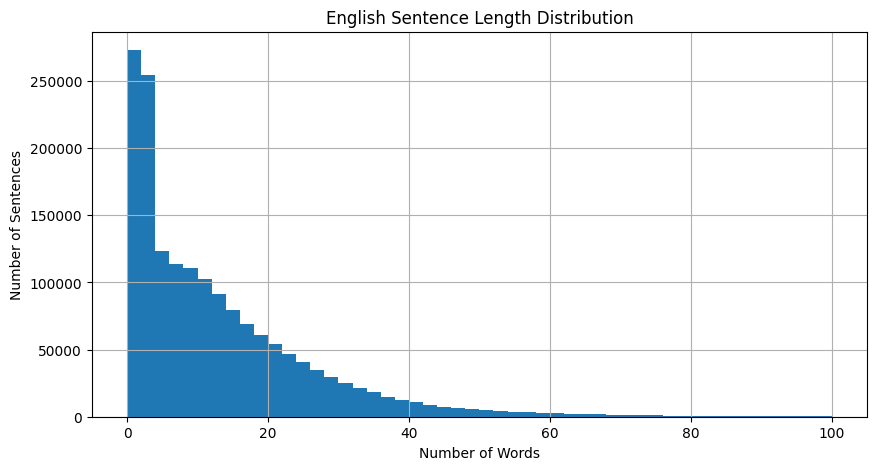

In [21]:
# ============================================================
# STEP 17: ENGLISH SENTENCE LENGTH DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Limit the graph to 100 words so very large outliers
# do not make the normal distribution difficult to see.
train_df.loc[
    train_df["english_word_count"] <= 100,
    "english_word_count"
].hist(
    bins=50
)

plt.title("English Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Sentences")

plt.show()

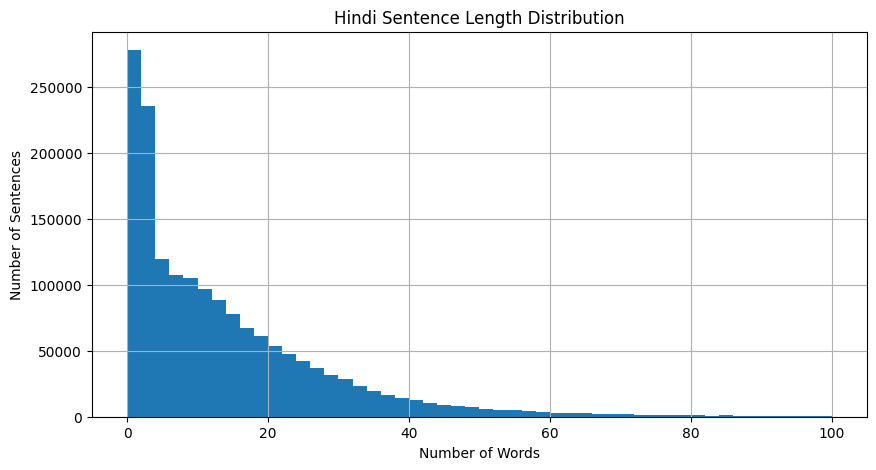

In [22]:
# ============================================================
# STEP 18: HINDI SENTENCE LENGTH DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 5))

train_df.loc[
    train_df["hindi_word_count"] <= 100,
    "hindi_word_count"
].hist(
    bins=50
)

plt.title("Hindi Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Sentences")

plt.show()

In [23]:
# ============================================================
# STEP 19: SAVE EDA PLOTS
# ============================================================

PLOTS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "plots"
)

# English plot
plt.figure(figsize=(10, 5))

train_df.loc[
    train_df["english_word_count"] <= 100,
    "english_word_count"
].hist(
    bins=50
)

plt.title("English Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Sentences")

english_plot_path = os.path.join(
    PLOTS_DIR,
    "english_sentence_length_distribution.png"
)

plt.savefig(
    english_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

# Hindi plot
plt.figure(figsize=(10, 5))

train_df.loc[
    train_df["hindi_word_count"] <= 100,
    "hindi_word_count"
].hist(
    bins=50
)

plt.title("Hindi Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Sentences")

hindi_plot_path = os.path.join(
    PLOTS_DIR,
    "hindi_sentence_length_distribution.png"
)

plt.savefig(
    hindi_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("EDA plots saved successfully.")
print(english_plot_path)
print(hindi_plot_path)

EDA plots saved successfully.
/content/drive/MyDrive/NNDL_English_Hindi_Translator/results/plots/english_sentence_length_distribution.png
/content/drive/MyDrive/NNDL_English_Hindi_Translator/results/plots/hindi_sentence_length_distribution.png


In [24]:
# ============================================================
# STEP 20: SAVE DATASET QUALITY SUMMARY
# ============================================================

summary_data = {
    "metric": [
        "training_rows",
        "validation_rows",
        "test_rows",
        "missing_english",
        "missing_hindi",
        "empty_english",
        "empty_hindi",
        "exact_duplicate_pairs"
    ],

    "value": [
        len(train_df),
        validation_parquet.metadata.num_rows,
        test_parquet.metadata.num_rows,
        train_df["english"].isnull().sum(),
        train_df["hindi"].isnull().sum(),
        empty_english,
        empty_hindi,
        duplicate_pairs
    ]
}

summary_df = pd.DataFrame(summary_data)

EDA_SUMMARY_PATH = os.path.join(
    PROJECT_ROOT,
    "results",
    "metrics",
    "dataset_quality_summary.csv"
)

summary_df.to_csv(
    EDA_SUMMARY_PATH,
    index=False
)

display(summary_df)

print("\nSaved to:")
print(EDA_SUMMARY_PATH)

,metric,value
0,training_rows,1659083
1,validation_rows,520
2,test_rows,2507
3,missing_english,0
4,missing_hindi,0
5,empty_english,721
6,empty_hindi,6047
7,exact_duplicate_pairs,219386



Saved to:
/content/drive/MyDrive/NNDL_English_Hindi_Translator/results/metrics/dataset_quality_summary.csv
